# InceptionV1 (GoogLeNet)

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [4]:
class InceptionModule(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3_reduce, ch3x3,
                 ch5x5_reduce, ch5x5, pool_proj):
        super().__init__()

        # path 1: conv 1x1
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, ch1x1, kernel_size=1),
            nn.ReLU(inplace=True),
        )

        # path 2: bottleneck 1x1 -> conv 3x3
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3_reduce, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch3x3_reduce, ch3x3, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        # path 3: bottleneck 1x1 -> conv 5x5
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5_reduce, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5_reduce, ch5x5, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
        )

        # path 4: max pool 3x3 -> conv 1x1
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        # concatenation (dim=1: [batch, channels, H, W])
        return torch.cat([b1, b2, b3, b4], dim=1)

In [5]:
test_module = InceptionModule(
    in_channels=192, ch1x1=64, ch3x3_reduce=96, ch3x3=128,
    ch5x5_reduce=16, ch5x5=32, pool_proj=32
).to(device)

test_input = torch.randn(2, 192, 28, 28).to(device)
test_output = test_module(test_input)
print(f"Input shape:  {test_input.shape}")
print(f"Output shape: {test_output.shape}")  # channels: 64+128+32+32 = 256

Input shape:  torch.Size([2, 192, 28, 28])
Output shape: torch.Size([2, 256, 28, 28])


In [9]:
class AuxiliaryClassifier(nn.Module):
    def __init__(self, in_channels, num_classes=10):
        super().__init__()
        
        self.pool = nn.AvgPool2d(kernel_size=5, stride=3)
        self.conv = nn.Conv2d(in_channels, 128, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)
        self.fc1 = nn.Linear(128 * 4 * 4, 1024)
        self.dropout = nn.Dropout(0.7)
        self.fc2 = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.pool(x)
        x = self.relu(self.conv(x))
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [10]:
class GoogLeNet(nn.Module):
    def __init__(self, num_classes=10, use_aux=True):
        super().__init__()
        self.use_aux = use_aux

        # stem: default conv + pool layers
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.Conv2d(64, 64, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.inception3a = InceptionModule(192, 64, 96, 128, 16, 32, 32)
        self.inception3b = InceptionModule(256, 128, 128, 192, 32, 96, 64)
        self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.inception4a = InceptionModule(480, 192, 96, 208, 16, 48, 64)
        self.inception4b = InceptionModule(512, 160, 112, 224, 24, 64, 64)
        self.inception4c = InceptionModule(512, 128, 128, 256, 24, 64, 64)
        self.inception4d = InceptionModule(512, 112, 144, 288, 32, 64, 64)
        self.inception4e = InceptionModule(528, 256, 160, 320, 32, 128, 128)
        self.maxpool4 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.inception5a = InceptionModule(832, 256, 160, 320, 32, 128, 128)
        self.inception5b = InceptionModule(832, 384, 192, 384, 48, 128, 128)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(1024, num_classes)

        if use_aux:
            self.aux1 = AuxiliaryClassifier(512, num_classes)
            self.aux2 = AuxiliaryClassifier(528, num_classes)

    def forward(self, x):
        x = self.stem(x)

        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool3(x)

        x = self.inception4a(x)
        aux1_out = self.aux1(x) if (self.use_aux and self.training) else None

        x = self.inception4b(x)
        x = self.inception4c(x)
        x = self.inception4d(x)
        aux2_out = self.aux2(x) if (self.use_aux and self.training) else None

        x = self.inception4e(x)
        x = self.maxpool4(x)

        x = self.inception5a(x)
        x = self.inception5b(x)

        x = self.avgpool(x)
        x = x.flatten(1)
        x = self.dropout(x)
        main_out = self.fc(x)

        if self.use_aux and self.training:
            return main_out, aux1_out, aux2_out
        return main_out

model = GoogLeNet(num_classes=10, use_aux=True).to(device)
print(model)

GoogLeNet(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (inception3a): InceptionModule(
    (branch1): Sequential(
      (0): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
    )
    (branch2): Sequential(
      (0): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(96, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
    (branch3): Sequential(
      (0): Conv2d(192, 16, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU(inpla

In [11]:
model.train()
train_out = model(images.to(device))
print(f"Train mode output: main={train_out[0].shape}, aux1={train_out[1].shape}, aux2={train_out[2].shape}")

model.eval()
with torch.no_grad():
    eval_out = model(images.to(device))
print(f"Eval mode output: {eval_out.shape}")  # только main, aux отброшены

Train mode output: main=torch.Size([64, 10]), aux1=torch.Size([64, 10]), aux2=torch.Size([64, 10])
Eval mode output: torch.Size([64, 10])


In [12]:
def count_conv_params(in_ch, out_ch, kernel_size):
    return (kernel_size * kernel_size * in_ch + 1) * out_ch

b1 = count_conv_params(192, 64, 1)
b2_reduce = count_conv_params(192, 96, 1)
b2_conv = count_conv_params(96, 128, 3)
b3_reduce = count_conv_params(192, 16, 1)
b3_conv = count_conv_params(16, 32, 5)
b4_proj = count_conv_params(192, 32, 1)

inception3a_manual = b1 + b2_reduce + b2_conv + b3_reduce + b3_conv + b4_proj
inception3a_torch = sum(p.numel() for p in model.inception3a.parameters())

print(f"Branch 1 (1x1): {b1:,}")
print(f"Branch 2 (1x1 reduce -> 3x3): {b2_reduce:,} + {b2_conv:,} = {b2_reduce + b2_conv:,}")
print(f"Branch 3 (1x1 reduce -> 5x5): {b3_reduce:,} + {b3_conv:,} = {b3_reduce + b3_conv:,}")
print(f"Branch 4 (pool -> 1x1): {b4_proj:,}")
print(f"Inception3a manual total: {inception3a_manual:,}")
print(f"Inception3a torch total:  {inception3a_torch:,}")
assert inception3a_manual == inception3a_torch, "Mismatch in inception3a parameter count"

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal model parameters: {total_params:,}")

Branch 1 (1x1): 12,352
Branch 2 (1x1 reduce -> 3x3): 18,528 + 110,720 = 129,248
Branch 3 (1x1 reduce -> 5x5): 3,088 + 12,832 = 15,920
Branch 4 (pool -> 1x1): 6,176
Inception3a manual total: 163,696
Inception3a torch total:  163,696

Total model parameters: 10,334,030


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

AUX_WEIGHT = 0.3

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device, aux_weight):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        main_out, aux1_out, aux2_out = model(images)

        main_loss = criterion(main_out, labels)
        aux1_loss = criterion(aux1_out, labels)
        aux2_loss = criterion(aux2_out, labels)
        loss = main_loss + aux_weight * (aux1_loss + aux2_loss)

        loss.backward()
        optimizer.step()

        total_loss += main_loss.item() * images.size(0)
        preds = main_out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [15]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, AUX_WEIGHT)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=2.2768 train_acc=0.1219 | val_loss=2.1400 val_acc=0.1832 | time=75.3s
Epoch 2/10 | train_loss=2.1473 train_acc=0.1884 | val_loss=2.1042 val_acc=0.1982 | time=66.0s
Epoch 3/10 | train_loss=2.1027 train_acc=0.2132 | val_loss=2.1169 val_acc=0.1995 | time=66.2s
Epoch 4/10 | train_loss=2.0644 train_acc=0.2386 | val_loss=1.9663 val_acc=0.2851 | time=66.3s
Epoch 5/10 | train_loss=1.9837 train_acc=0.2873 | val_loss=1.9106 val_acc=0.3210 | time=66.4s
Epoch 6/10 | train_loss=1.8933 train_acc=0.3232 | val_loss=1.7582 val_acc=0.3817 | time=68.1s
Epoch 7/10 | train_loss=1.8352 train_acc=0.3476 | val_loss=1.8041 val_acc=0.3776 | time=68.4s
Epoch 8/10 | train_loss=1.7891 train_acc=0.3658 | val_loss=1.6774 val_acc=0.4189 | time=66.4s
Epoch 9/10 | train_loss=1.7326 train_acc=0.3923 | val_loss=1.6760 val_acc=0.4201 | time=66.4s
Epoch 10/10 | train_loss=1.6729 train_acc=0.4161 | val_loss=1.5527 val_acc=0.4769 | time=66.2s


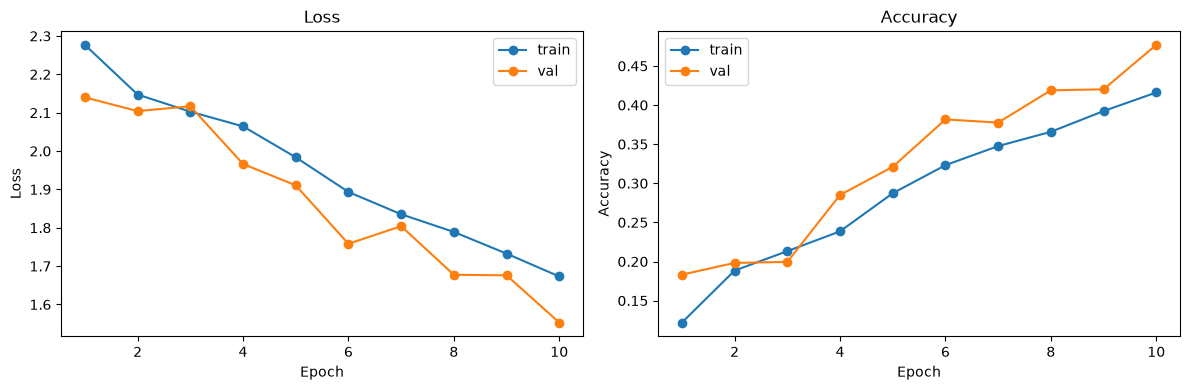

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

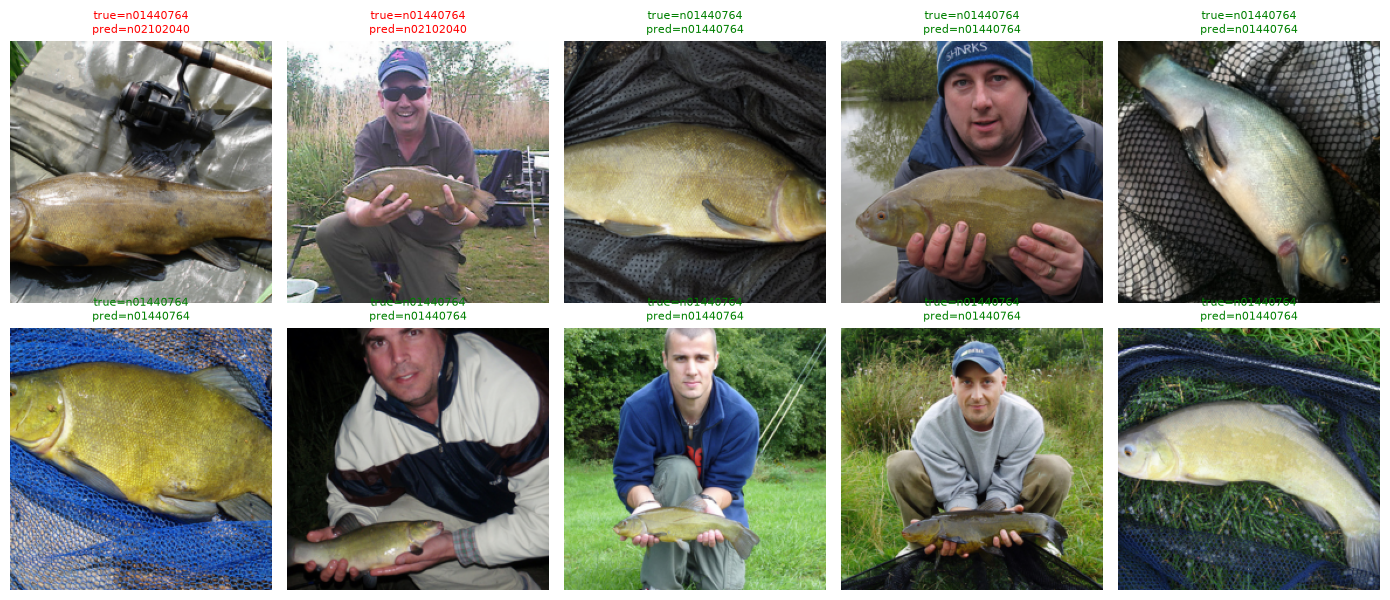

In [17]:
model.eval()
sample_images, sample_labels = next(iter(val_loader))
class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: see output above. Despite
being deeper (22 layers) than VGG16/VGG19, GoogLeNet has dramatically fewer
parameters (~6-7M vs ~138-144M), thanks to 1x1 bottleneck convolutions
inside each Inception module and global average pooling replacing the large
fully connected layers used in AlexNet/VGG.

**Why auxiliary classifiers instead of batch normalization.** Like VGG,this network has no batch normalization (not yet invented in 2014). Unlike VGG, GoogLeNet's original design already includes a countermeasure for
vanishing gradients on a 22-layer network: two auxiliary classifiersattached partway through the network, whose loss (weighted by 0.3, as in the original paper) is added to the main loss during training only. They are discarded at inference time.